In [4]:
# ================================
# EXTRACCIÓN HOG (S0 - TrashNet)
# ================================
import os, time, cv2
import numpy as np
from skimage.feature import hog

data_dir = "../../data_preprocessed/HOG_SVM/TrashNet"

X, y = [], []

print("Extrayendo características HOG...")
inicio = time.time()

for clase in sorted(os.listdir(data_dir)):
    clase_path = os.path.join(data_dir, clase)
    if not os.path.isdir(clase_path):
        continue
    for img_name in os.listdir(clase_path):
        img_path = os.path.join(clase_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=False
        )
        X.append(features)
        y.append(clase)

print(f"Listo. Total imágenes: {len(X)}")
print(f"Dimensión HOG: {X[0].shape}")


Extrayendo características HOG...
Listo. Total imágenes: 2499
Dimensión HOG: (8100,)


Ejecutando Grid Search para S0 (TrashNet)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Grid Search completado en 3628.76 segundos
Mejores hiperparámetros encontrados:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

=== REPORTE DE CLASIFICACIÓN (S0 - TrashNet + Grid Search) ===
              precision    recall  f1-score   support

   cardboard       0.69      0.76      0.73        80
       glass       0.57      0.61      0.59       100
       metal       0.62      0.60      0.61        82
       paper       0.76      0.82      0.79       115
     plastic       0.61      0.58      0.60        96
       trash       1.00      0.41      0.58        27

    accuracy                           0.66       500
   macro avg       0.71      0.63      0.65       500
weighted avg       0.67      0.66      0.66       500



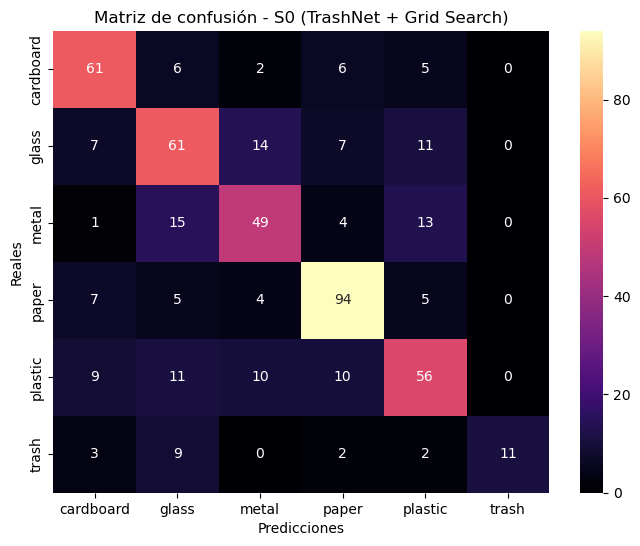

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ================================
# SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# PIPELINE: ESCALADO + SVM
# ================================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

# ================================
# GRID SEARCH
# ================================
param_grid = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001]  # solo afecta a rbf
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("Ejecutando Grid Search para S0 (TrashNet)...")
inicio = time.time()
grid.fit(X_train, y_train)
fin = time.time()

print(f"\nGrid Search completado en {fin - inicio:.2f} segundos")

# ================================
# MEJOR MODELO
# ================================
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)

best_model = grid.best_estimator_

# ================================
# EVALUACIÓN FINAL
# ================================
y_pred = best_model.predict(X_test)

print("\n=== REPORTE DE CLASIFICACIÓN (S0 - TrashNet + Grid Search) ===")
print(classification_report(y_test, y_pred))

# ================================
# MATRIZ DE CONFUSIÓN
# ================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='magma',
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)
plt.xlabel("Predicciones")
plt.ylabel("Reales")
plt.title("Matriz de confusión - S0 (TrashNet + Grid Search)")
plt.show()


In [6]:
# ================================
# EXTRACCIÓN HOG (S1 - TACO)
# ================================
import os, time, cv2
import numpy as np
from skimage.feature import hog

data_dir = "../../data_preprocessed/HOG_SVM/TACO"

X, y = [], []

print("Extrayendo características HOG para TACO...")
inicio = time.time()

for clase in sorted(os.listdir(data_dir)):
    clase_path = os.path.join(data_dir, clase)
    if not os.path.isdir(clase_path):
        continue
    for img_name in os.listdir(clase_path):
        img_path = os.path.join(clase_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=False
        )
        X.append(features)
        y.append(clase)

fin = time.time()
print(f"Extracción completada en {fin - inicio:.2f} segundos")
print(f"Total imágenes TACO: {len(X)}")
print(f"Dimensión HOG: {X[0].shape}")


Extrayendo características HOG para TACO...
Extracción completada en 20.24 segundos
Total imágenes TACO: 4374
Dimensión HOG: (8100,)


In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np

# ================================
# SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# PIPELINE
# ================================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

# ================================
# GRID
# ================================
param_grid = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("Ejecutando Grid Search para S1 (TACO)...")
inicio = time.time()
grid.fit(X_train, y_train)
print(f"Tiempo total: {time.time() - inicio:.2f} s")

print("\nMejores hiperparámetros S1 (TACO):")
print(grid.best_params_)

best_model = grid.best_estimator_

# ================================
# EVALUACIÓN
# ================================
y_pred = best_model.predict(X_test)

print("\n=== REPORTE DE CLASIFICACIÓN (S1 - TACO + Grid Search) ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.title("Matriz de confusión - S1 (TACO + Grid Search)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


Ejecutando Grid Search para S1 (TACO)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 